# Phase 1 — Step 1: Dataset Load & EDA
**Project:** Elder Abuse Detection & Legal Assistance — CSE 499A, NSU Spring 2026  
**Dataset:** `data/Elder_abuse_Dataset.csv` (199 cases)

---

## Cell 1 — Libraries Import

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
})

OUT_DIR = '../data'
DPI     = 180

RICH_PALETTE = [
    '#E63946','#2A9D8F','#E9C46A','#264653','#F4A261',
    '#A8DADC','#457B9D','#1D3557','#6D6875','#B5838D',
    '#E76F51','#52B788','#90E0EF','#C77DFF','#F72585',
    '#4CC9F0','#FF9F1C','#CBFF8C','#8338EC','#FB5607',
]
def make_colors(n):
    return RICH_PALETTE[:n] if n <= len(RICH_PALETTE) else (RICH_PALETTE * 3)[:n]

def save_chart(name):
    plt.savefig(f'{OUT_DIR}/{name}.png', dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'[OK] {name}.png saved')

print('Libraries loaded')

Libraries loaded


## Cell 2 — Dataset Load

In [104]:
df = pd.read_csv('../data/Elder_abuse_Dataset.csv', encoding='utf-8')

# Strip all string columns to avoid trailing-space issues
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'Total rows    : {len(df)}')
print(f'Total columns : {len(df.columns)}')
print()
df.head()

Total rows    : 199
Total columns : 12



,Data Type,Date,Source,Location,Abuse Relation,Abuse Category,Gender,Name,Age,Scenerio(Bangla),Scenerio(English),URL / Source type
0,Secondary (News),"13 February , 2022",jugantor.com,Dhaka,Family,Neglect,Male,Abu Mohsin Khan,Unknown,পরিবারের অবহেলার কারণে আবু মহসিন আত্মহত্যা করে...,Abu Mohsin did suicide because his family negl...,https://www.jugantor.com/tp-ub-editorial/519945
1,Secondary (News),"26 February ,2024",jugantor.com,Dhaka,Children,Physical,Female,Khurshida Khatun,Unknown,মা তার ছেলেদের দ্বারা শারীরিক নির্যাতনের শিকার...,Mother was physically abused by her sons,https://www.jugantor.com/capital/778487
2,Secondary (News),"21 May , 2024",jugantor.com,Sherpur,Son,Financial Exploitation and physical,Female,Alpona Begum,45,পারিবারিক খরচের জন্য জমি লিখিয়ে নিতে মায়ের প...,Son breaks mother's leg after asking for money...,https://www.jugantor.com/country-news/807701
3,Secondary (News),"24 december , 2024",jagonews24.com,Shariyatpur,Children,Abandonment,Male,Sakib Ali Sardar,Unknown,জঙ্গলে পরিত্যক্ত এক অসুস্থ বৃদ্ধের শেষ পরিণতি ...,Sick old man abandoned in forest ends up in ol...,https://www.jagonews24.com/country/news/990195
4,Secondary (News),"23 February , 2023",prothomalo.com,Noakhali,Neighbors,Physical,Female,Anonymous,40,টিকটকে মা ও মেয়েকে বেঁধে নির্যাতন করার ভিডিও ...,Case filed over video of mother and daughter t...,https://www.prothomalo.com/bangladesh/district...


## Cell 3 — Column Names

In [105]:
print('All Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

All Columns:
   1. Data Type
   2. Date
   3. Source
   4. Location
   5. Abuse Relation
   6. Abuse Category
   7. Gender
   8. Name
   9. Age
  10. Scenerio(Bangla)
  11. Scenerio(English)
  12. URL / Source type


## Cell 4 — Data Types & Basic Info

In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Data Type          199 non-null    str  
 1   Date               199 non-null    str  
 2   Source             199 non-null    str  
 3   Location           199 non-null    str  
 4   Abuse Relation     199 non-null    str  
 5   Abuse Category     199 non-null    str  
 6   Gender             199 non-null    str  
 7   Name               199 non-null    str  
 8   Age                199 non-null    str  
 9   Scenerio(Bangla)   199 non-null    str  
 10  Scenerio(English)  199 non-null    str  
 11  URL / Source type  199 non-null    str  
dtypes: str(12)
memory usage: 18.8 KB


## Cell 5 — Missing Values

In [107]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if missing_df.empty:
    print('No missing values found')
else:
    print('Columns with missing values:')
    print(missing_df.to_string())

No missing values found


## Cell 6 — Normalize Columns (Category, Relation, Age, Date, Severity)

In [108]:
# ── Abuse Category normalize ──────────────────────────────────────
cat_map = {
    'Physical':                                         'Physical Abuse',
    'Physcial':                                         'Physical Abuse',
    'Physical Abuse':                                   'Physical Abuse',
    'Physical and neglect':                             'Physical Abuse',
    'Verbally':                                         'Verbal Abuse',
    'verbally':                                         'Verbal Abuse',
    'Abandonment and physical':                         'Physical + Abandonment',
    'Neglect and Abandonment':                          'Neglect + Abandonment',
    'Financial Exploitation and Abandonment':           'Financial + Abandonment',
    'Financial Exploitation and physical':              'Financial + Physical',
    'Financial Exploitation and neglect':               'Financial + Neglect',
    'Financial Exploitation and Murder':                'Financial + Murder',
    'Financial Exploitation and Neglect':               'Financial + Neglect',
    'Financial Exploitation, physical and abandonment': 'Financial + Physical + Abandonment',
}
df['Category_Norm'] = df['Abuse Category'].replace(cat_map).fillna(df['Abuse Category'])

# ── Abuse Relation normalize ──────────────────────────────────────
rel_map = {
    'Son and daughter-in-law':          'Son & Daughter-in-law',
    'Son':                              'Son',
    'Children':                         'Children',
    'Daughter-in-law':                  'Daughter-in-law',
    'Family':                           'Family',
    'Neighbor':                         'Neighbor',
    'Relative':                         'Relative',
    'Neighbors':                        'Neighbor',
    'Homemaid':                         'House Help',
    'Landlord':                         'Landlord',
    'Grand son':                        'Grandchild',
    'Wife and Children':                'Spouse & Children',
    'Nephew and his wife':              'Nephew & Wife',
    'Husband and daughter-in-law':      'Husband & D-in-law',
    'Son-in-law and Grand son':         'Son-in-law & Grandson',
    'Son, daughter-in-law and grand son': 'Son & Family',
    'Son and Grand son':                'Son & Grandchild',
    'Union Council Member':             'Govt. Official',
    'Police':                           'Govt. Official',
}
df['Relation_Norm'] = df['Abuse Relation'].replace(rel_map).fillna(df['Abuse Relation'])

# ── Age numeric ───────────────────────────────────────────────────
df['Age_Numeric'] = pd.to_numeric(df['Age'], errors='coerce')

# ── Date & Year ───────────────────────────────────────────────────
df['Date_Parsed'] = pd.to_datetime(df['Date'], errors='coerce', dayfirst=True)
df['Year'] = df['Date_Parsed'].dt.year

# ── Severity Score (1-5) ──────────────────────────────────────────
severity_map = {
    'Murder': 5, 'Financial + Murder': 5,
    'Physical Abuse': 4, 'Financial + Physical': 4,
    'Physical + Abandonment': 4, 'Financial + Physical + Abandonment': 4,
    'Abandonment': 3, 'Neglect + Abandonment': 3, 'Financial + Abandonment': 3,
    'Financial Exploitation': 2, 'Neglect': 2, 'Financial + Neglect': 2,
    'Verbal Abuse': 1,
}
df['Severity_Score'] = df['Category_Norm'].map(severity_map).fillna(2)

# ── Trust Blind Spot ──────────────────────────────────────────────
family_kw = ['son','daughter','spouse','husband','wife','child','nephew','grandchild']
df['Trust_Blind_Spot'] = df['Relation_Norm'].str.lower().str.contains(
    '|'.join(family_kw), na=False).astype(int)

print(f'Category_Norm unique  : {df["Category_Norm"].nunique()}')
print(f'Relation_Norm unique  : {df["Relation_Norm"].nunique()}')
print(f'Age valid             : {df["Age_Numeric"].notna().sum()} / {len(df)}')
print(f'Trust Blind Spot      : {df["Trust_Blind_Spot"].sum()} cases ({df["Trust_Blind_Spot"].mean()*100:.1f}%)')
print(f'Severity Score range  : {int(df["Severity_Score"].min())} – {int(df["Severity_Score"].max())}')

Category_Norm unique  : 13
Relation_Norm unique  : 21
Age valid             : 163 / 199
Trust Blind Spot      : 165 cases (82.9%)
Severity Score range  : 1 – 5


## Cell 7 — Abuse Category (Raw counts)

In [109]:
print('Abuse Category (Normalized):')
print(df['Category_Norm'].value_counts().to_string())

Abuse Category (Normalized):
Category_Norm
Abandonment                           45
Physical Abuse                        38
Neglect                               34
Financial + Physical                  20
Verbal Abuse                          18
Murder                                14
Neglect + Abandonment                 12
Financial + Abandonment                8
Financial Exploitation                 3
Physical + Abandonment                 3
Financial + Neglect                    2
Financial + Physical + Abandonment     1
Financial + Murder                     1


## Cell 8 — Abuse Relation (cleaned)

In [110]:
print('Abuse Relation (Normalized):')
print(df['Relation_Norm'].value_counts().to_string())

Abuse Relation (Normalized):
Relation_Norm
Son                      76
Children                 39
Son & Daughter-in-law    27
Family                   17
Daughter-in-law           8
Relative                  8
Daughter                  5
Neighbor                  3
Nephew & Wife             2
Govt. Official            2
Grandchild                2
Younger Brother           1
Spouse & Children         1
Son & Family              1
Son-in-law & Grandson     1
Son & Grandchild          1
Husband & D-in-law        1
Landlord                  1
House Help                1
Unknown                   1
Wife                      1


## Cell 9 — Gender, Source, Age, Location

In [111]:
print('--- Gender ---')
print(df['Gender'].value_counts().to_string())
print()
print('--- Data Type ---')
print(df['Data Type'].value_counts().to_string())
print()
print('--- Age Stats ---')
print(f'  Valid: {df["Age_Numeric"].notna().sum()}  |  Min: {df["Age_Numeric"].min():.0f}  |  Max: {df["Age_Numeric"].max():.0f}  |  Mean: {df["Age_Numeric"].mean():.1f}')
print()
print('--- Top 15 Locations ---')
loc_c = df['Location'].value_counts()
loc_c = loc_c[loc_c.index.str.lower() != 'unknown'].head(15)
print(loc_c.to_string())

--- Gender ---
Gender
Male             103
Female            82
Male & Female     14

--- Data Type ---
Data Type
Primary (Interview)      104
Secondary (News)          72
Secondary(Interview)      16
Secondary (Interview)      5
primary (Interview)        2

--- Age Stats ---
  Valid: 163  |  Min: 40  |  Max: 107  |  Mean: 72.9

--- Top 15 Locations ---
Location
Dhaka          33
Narayanganj    28
Faridpur       18
Chittagong     13
Madaripur      11
Lakshmipur     10
Noakhali        7
Pabna           5
Mymenshingh     4
Rajshahi        4
Jessore         4
Comilla         3
Patuakhali      3
Barisal         3
Kurigram        2


---
## Charts (11 total)
All charts auto-saved to `data/` folder.

## Chart 1 — Abuse Category Distribution

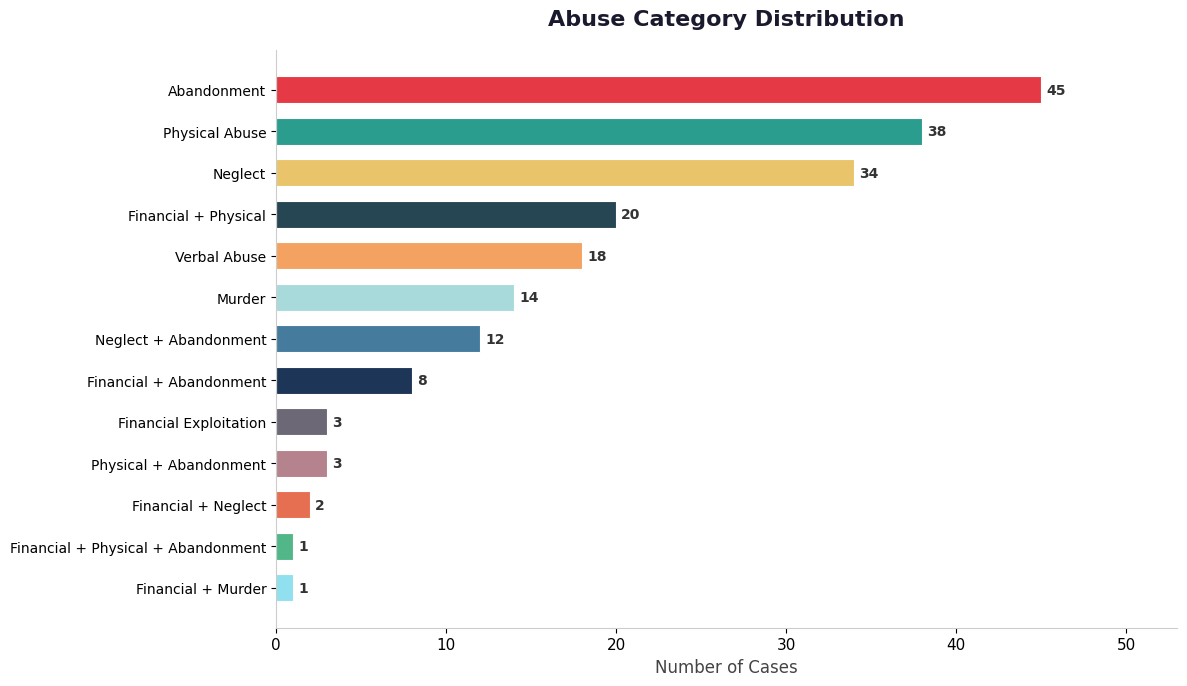

[OK] chart_01_abuse_category.png saved


In [112]:
counts = df['Category_Norm'].value_counts()
colors = make_colors(len(counts))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(counts.index[::-1], counts.values[::-1],
               color=colors[::-1], height=0.65, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', ha='left', fontsize=10,
            fontweight='bold', color='#333333')

ax.set_title('Abuse Category Distribution', fontsize=16, fontweight='bold', pad=18, color='#1a1a2e')
ax.set_xlabel('Number of Cases', fontsize=12, color='#444')
ax.set_xlim(0, counts.max() + 8)
ax.tick_params(axis='y', labelsize=10)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_01_abuse_category')

## Chart 2 — Abuser Relation Distribution

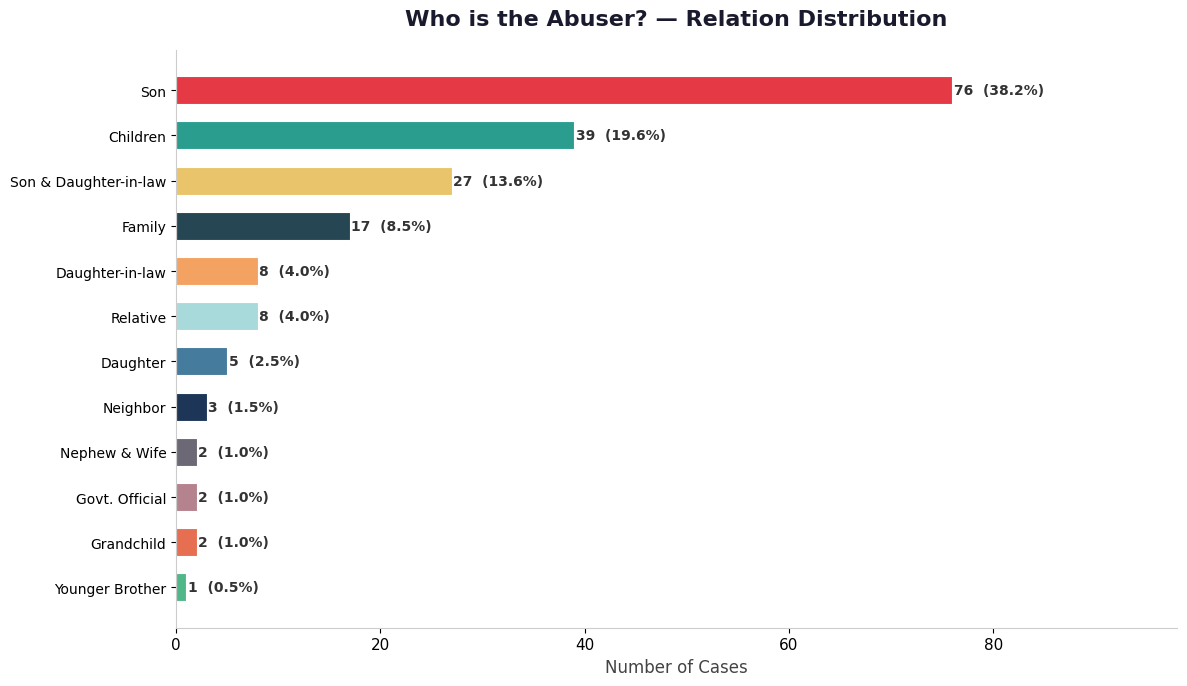

[OK] chart_02_abuser_relation.png saved


In [113]:
rel_counts = df['Relation_Norm'].value_counts().head(12)
colors2    = make_colors(len(rel_counts))

fig, ax = plt.subplots(figsize=(12, 7))
bars2 = ax.barh(rel_counts.index[::-1], rel_counts.values[::-1],
                color=colors2[::-1], height=0.62, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars2, rel_counts.values[::-1]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f"{val}  ({val/len(df)*100:.1f}%)",
            va='center', ha='left', fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Who is the Abuser? — Relation Distribution', fontsize=16,
             fontweight='bold', pad=18, color='#1a1a2e')
ax.set_xlabel('Number of Cases', fontsize=12, color='#444')
ax.set_xlim(0, rel_counts.max() + 22)
ax.tick_params(axis='y', labelsize=10)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_02_abuser_relation')

## Chart 3 — Top 15 Locations

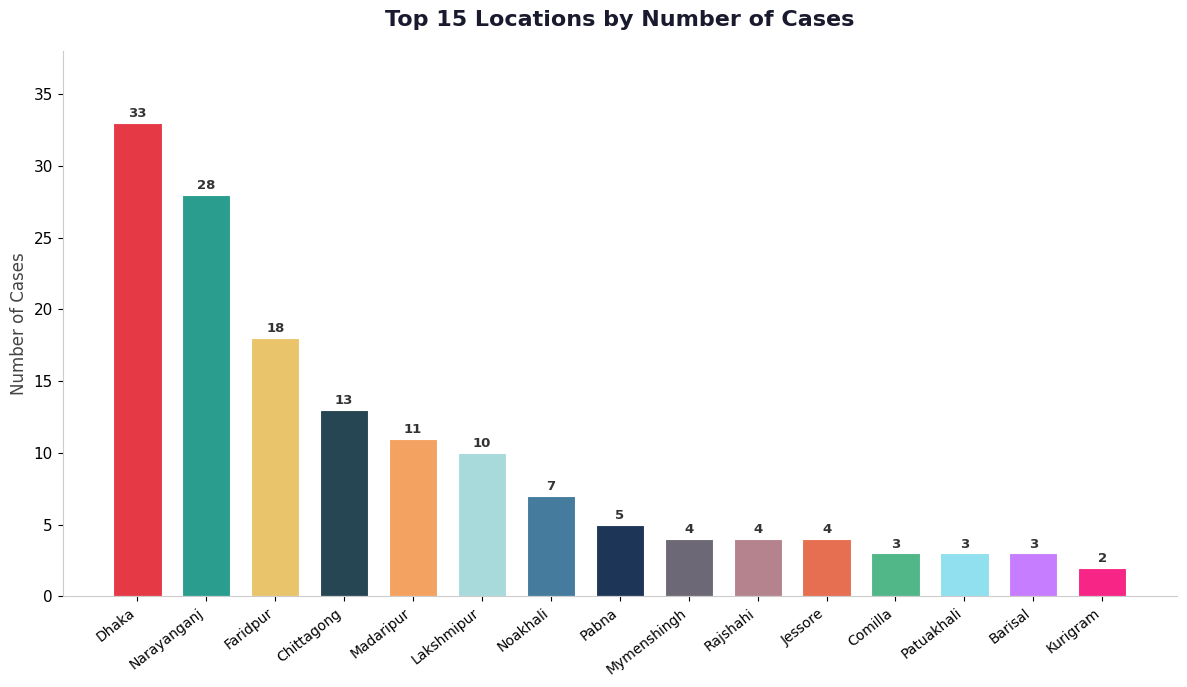

[OK] chart_03_top15_locations.png saved


In [114]:
loc_counts = df['Location'].value_counts()
loc_counts = loc_counts[loc_counts.index.str.lower() != 'unknown'].head(15)
colors3    = make_colors(len(loc_counts))

fig, ax = plt.subplots(figsize=(12, 7))
bars3 = ax.bar(range(len(loc_counts)), loc_counts.values,
               color=colors3, edgecolor='white', linewidth=0.8, width=0.7)

for bar, val in zip(bars3, loc_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            str(val), ha='center', va='bottom', fontsize=9.5,
            fontweight='bold', color='#333333')

ax.set_xticks(range(len(loc_counts)))
ax.set_xticklabels(loc_counts.index, rotation=38, ha='right', fontsize=10)
ax.set_title('Top 15 Locations by Number of Cases', fontsize=16,
             fontweight='bold', pad=18, color='#1a1a2e')
ax.set_ylabel('Number of Cases', fontsize=12, color='#444')
ax.set_ylim(0, loc_counts.max() + 5)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_03_top15_locations')

## Chart 4 — Gender Distribution (Pie)

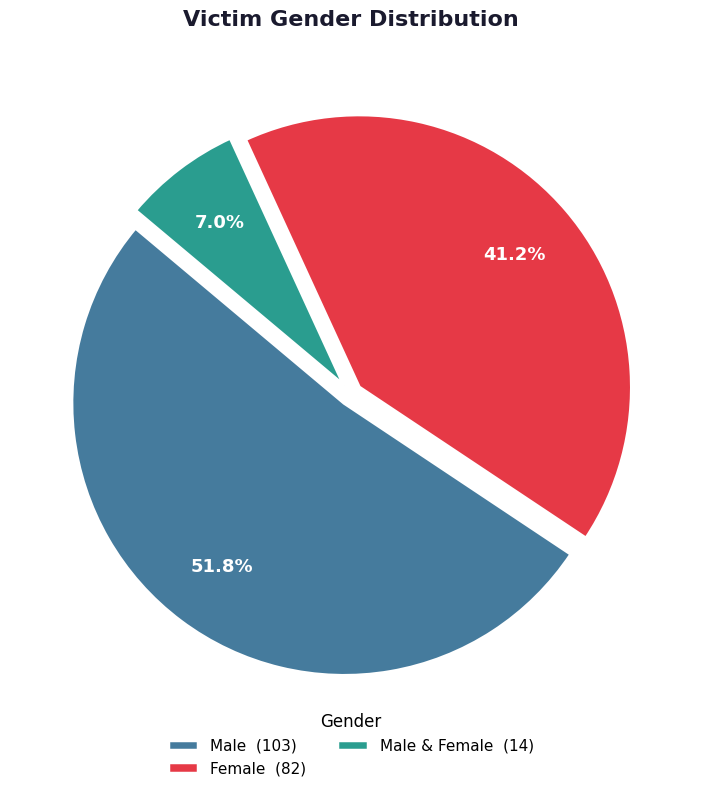

[OK] chart_04_gender_pie.png saved


In [115]:
gen_counts = df['Gender'].value_counts()
pie_colors = ['#457B9D','#E63946','#2A9D8F','#E9C46A'][:len(gen_counts)]

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    gen_counts.values, labels=None, autopct='%1.1f%%',
    colors=pie_colors, startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    explode=[0.04]*len(gen_counts))
for t in autotexts:
    t.set_fontsize(13); t.set_fontweight('bold'); t.set_color('white')

legend_labels = [f"{g}  ({v})" for g, v in zip(gen_counts.index, gen_counts.values)]
ax.legend(wedges, legend_labels, title='Gender', title_fontsize=12,
          fontsize=11, loc='lower center', bbox_to_anchor=(0.5,-0.08), ncol=2, frameon=False)
ax.set_title('Victim Gender Distribution', fontsize=16, fontweight='bold', pad=20, color='#1a1a2e')
plt.tight_layout()
save_chart('chart_04_gender_pie')

## Chart 5 — Severity Score Distribution

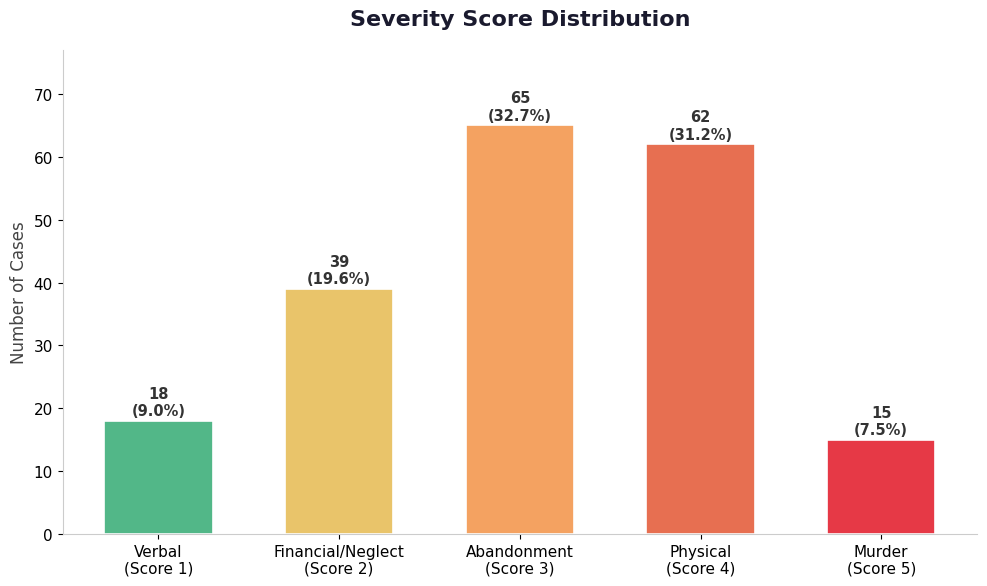

[OK] chart_05_severity_score.png saved


In [116]:
sev_labels = {1:'Verbal\n(Score 1)', 2:'Financial/Neglect\n(Score 2)',
              3:'Abandonment\n(Score 3)', 4:'Physical\n(Score 4)', 5:'Murder\n(Score 5)'}
sev_counts = df['Severity_Score'].value_counts().sort_index()
sev_colors = ['#52B788','#E9C46A','#F4A261','#E76F51','#E63946']

fig, ax = plt.subplots(figsize=(10, 6))
bars5 = ax.bar([sev_labels[s] for s in sev_counts.index],
               sev_counts.values,
               color=[sev_colors[int(i)-1] for i in sev_counts.index],
               edgecolor='white', linewidth=1.2, width=0.6)

for bar, val in zip(bars5, sev_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
            f"{val}\n({val/len(df)*100:.1f}%)",
            ha='center', va='bottom', fontsize=10.5, fontweight='bold', color='#333333')

ax.set_title('Severity Score Distribution', fontsize=16, fontweight='bold', pad=18, color='#1a1a2e')
ax.set_ylabel('Number of Cases', fontsize=12, color='#444')
ax.set_ylim(0, sev_counts.max()+12)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_05_severity_score')

## Chart 6 — Age Distribution

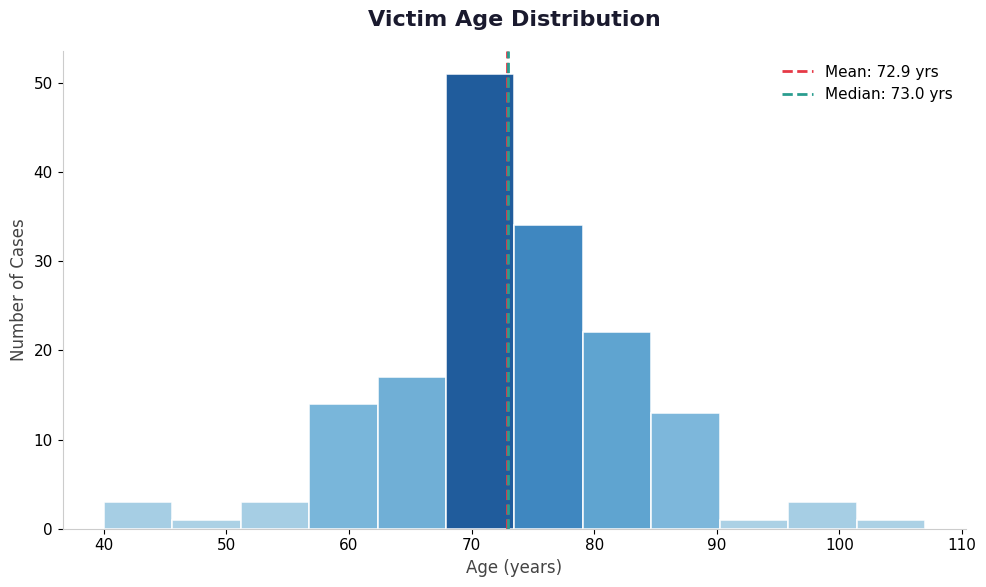

[OK] chart_06_age_distribution.png saved


In [117]:
age_data = df['Age_Numeric'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
n, bins, patches = ax.hist(age_data, bins=12, edgecolor='white', linewidth=1.2, color='#457B9D', alpha=0.9)

cmap = plt.cm.Blues
for patch, val in zip(patches, n):
    patch.set_facecolor(cmap(0.35 + 0.55 * val / n.max()))

ax.axvline(age_data.mean(),   color='#E63946', linestyle='--', linewidth=2, label=f'Mean: {age_data.mean():.1f} yrs')
ax.axvline(age_data.median(), color='#2A9D8F', linestyle='--', linewidth=2, label=f'Median: {age_data.median():.1f} yrs')

ax.set_title('Victim Age Distribution', fontsize=16, fontweight='bold', pad=18, color='#1a1a2e')
ax.set_xlabel('Age (years)', fontsize=12, color='#444')
ax.set_ylabel('Number of Cases', fontsize=12, color='#444')
ax.legend(fontsize=11, frameon=False)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_06_age_distribution')

## Chart 7 — Year-wise Case Trend

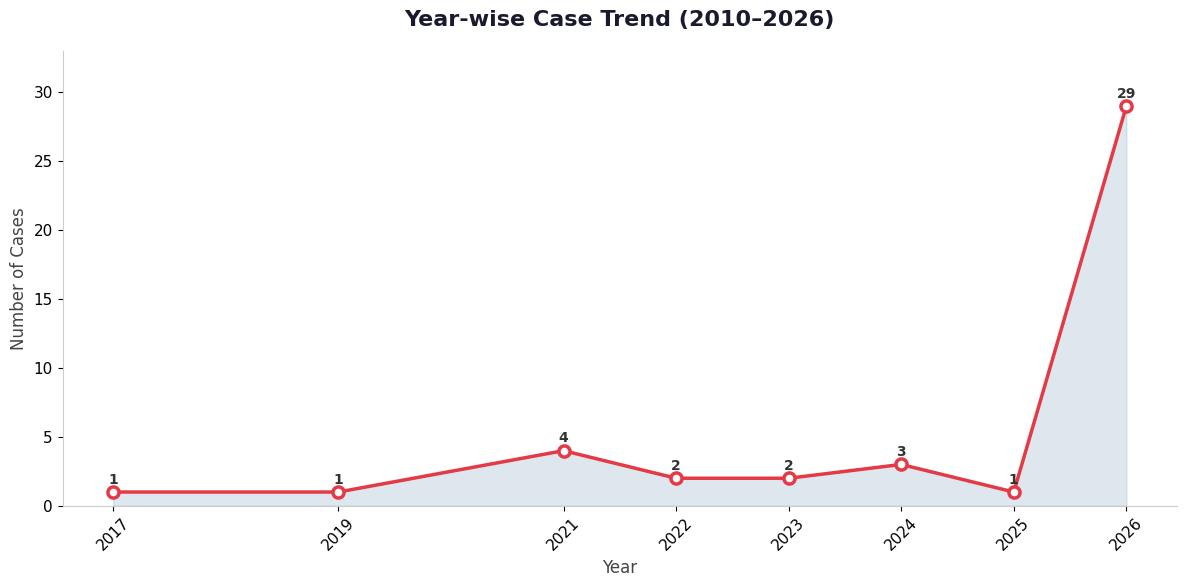

[OK] chart_07_year_trend.png saved


In [118]:
year_counts = df['Year'].dropna().astype(int).value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2010]

fig, ax = plt.subplots(figsize=(12, 6))
ax.fill_between(year_counts.index, year_counts.values, alpha=0.18, color='#457B9D')
ax.plot(year_counts.index, year_counts.values, marker='o', markersize=8,
        color='#E63946', linewidth=2.5, markerfacecolor='white',
        markeredgecolor='#E63946', markeredgewidth=2.5)

for x, y in zip(year_counts.index, year_counts.values):
    ax.text(x, y+0.4, str(y), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Year-wise Case Trend (2010–2026)', fontsize=16, fontweight='bold', pad=18, color='#1a1a2e')
ax.set_xlabel('Year', fontsize=12, color='#444')
ax.set_ylabel('Number of Cases', fontsize=12, color='#444')
ax.set_xticks(year_counts.index)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0, year_counts.max()+4)
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_07_year_trend')

## Chart 8 — Heatmap: Abuse Category × Abuser Relation

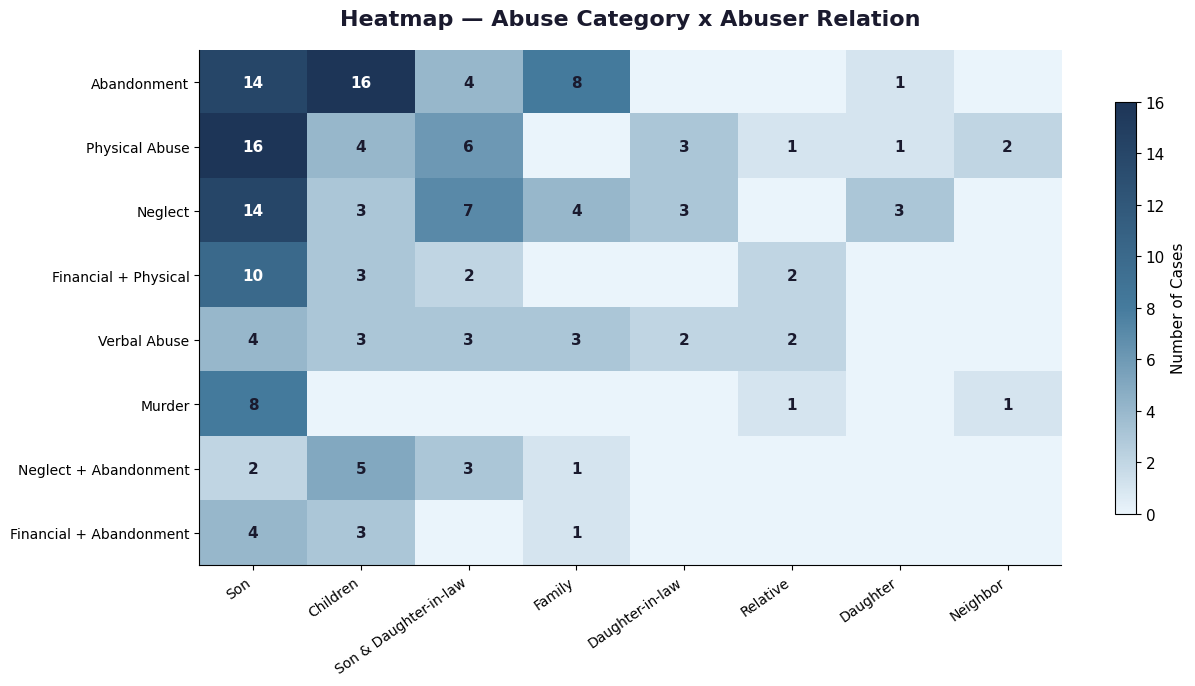

[OK] chart_08_heatmap_cat_relation.png saved


In [119]:
top_cats = df['Category_Norm'].value_counts().head(8).index.tolist()
top_rels = df['Relation_Norm'].value_counts().head(8).index.tolist()

heat_df = df[df['Category_Norm'].isin(top_cats) & df['Relation_Norm'].isin(top_rels)]
pivot   = heat_df.pivot_table(index='Category_Norm', columns='Relation_Norm',
                               aggfunc='size', fill_value=0)
pivot   = pivot.loc[[c for c in top_cats if c in pivot.index]]
pivot   = pivot[[c for c in top_rels if c in pivot.columns]]

cmap_heat = LinearSegmentedColormap.from_list('heat', ['#EAF4FB','#457B9D','#1D3557'])
fig, ax = plt.subplots(figsize=(13, 7))
im = ax.imshow(pivot.values, aspect='auto', cmap=cmap_heat)

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels(pivot.columns, rotation=35, ha='right', fontsize=10)
ax.set_yticklabels(pivot.index, fontsize=10)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if val > 0:
            text_color = 'white' if val > pivot.values.max()*0.5 else '#1a1a2e'
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=11, fontweight='bold', color=text_color)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Number of Cases', fontsize=11)
ax.set_title('Heatmap — Abuse Category x Abuser Relation', fontsize=16,
             fontweight='bold', pad=18, color='#1a1a2e')
plt.tight_layout()
save_chart('chart_08_heatmap_cat_relation')

## Chart 9 — Trust Blind Spot Analysis

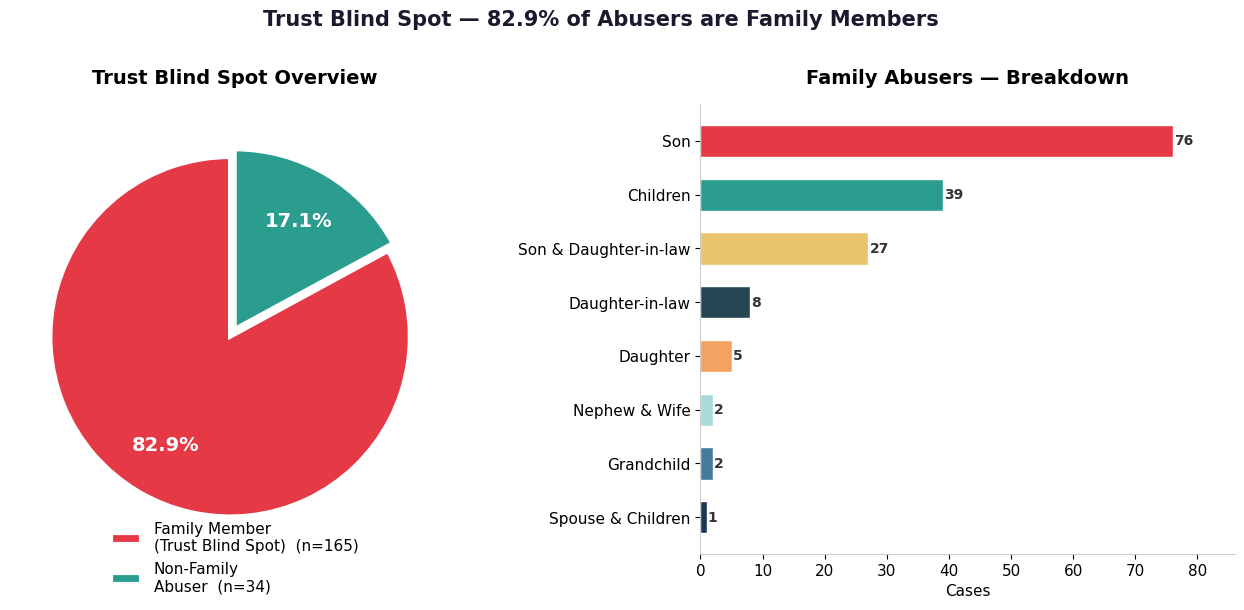

[OK] chart_09_trust_blind_spot.png saved


In [120]:
tbs_family = df['Trust_Blind_Spot'].sum()
tbs_other  = len(df) - tbs_family
tbs_labels = ['Family Member\n(Trust Blind Spot)', 'Non-Family\nAbuser']
tbs_vals   = [tbs_family, tbs_other]
tbs_colors = ['#E63946','#2A9D8F']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

wedges, texts, autos = ax1.pie(
    tbs_vals, labels=None, autopct='%1.1f%%', colors=tbs_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':3}, pctdistance=0.70, explode=[0.05,0])
for t in autos:
    t.set_fontsize(14); t.set_fontweight('bold'); t.set_color('white')
ax1.legend(wedges, [f"{l}  (n={v})" for l,v in zip(tbs_labels,tbs_vals)],
           fontsize=11, loc='lower center', bbox_to_anchor=(0.5,-0.12), frameon=False)
ax1.set_title('Trust Blind Spot Overview', fontsize=14, fontweight='bold', pad=15)

family_rels = df[df['Trust_Blind_Spot']==1]['Relation_Norm'].value_counts().head(8)
fam_colors  = make_colors(len(family_rels))
ax2.barh(family_rels.index[::-1], family_rels.values[::-1],
         color=fam_colors[::-1], height=0.6, edgecolor='white')
for i, val in enumerate(family_rels.values[::-1]):
    ax2.text(val+0.2, i, str(val), va='center', fontsize=10,
             fontweight='bold', color='#333333')
ax2.set_title('Family Abusers — Breakdown', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Cases', fontsize=11)
ax2.set_xlim(0, family_rels.max()+10)
ax2.grid(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')

fig.suptitle(
    f'Trust Blind Spot — {tbs_family/len(df)*100:.1f}% of Abusers are Family Members',
    fontsize=15, fontweight='bold', color='#1a1a2e', y=1.01)
plt.tight_layout()
save_chart('chart_09_trust_blind_spot')

## Chart 10 — Data Source Type Distribution

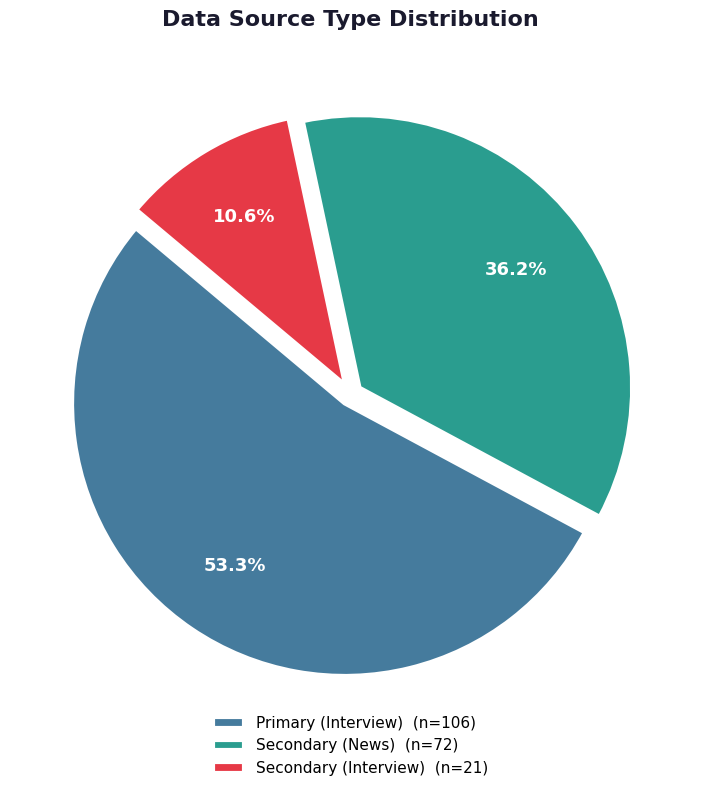

[OK] chart_10_data_source_type.png saved


In [121]:
# Normalize source type (strip + merge variants)
df['Source_Norm'] = df['Data Type'].str.replace(r'[Pp]rimary\s*\(Interview\)', 'Primary (Interview)', regex=True)
df['Source_Norm'] = df['Source_Norm'].str.replace(r'[Ss]econdary\s*\(?Interview\)?', 'Secondary (Interview)', regex=True)
src_counts = df['Source_Norm'].value_counts()
src_colors = ['#457B9D','#2A9D8F','#E63946'][:len(src_counts)]

fig, ax = plt.subplots(figsize=(8, 8))
wedges2, texts2, autos2 = ax.pie(
    src_counts.values, labels=None, autopct='%1.1f%%',
    colors=src_colors, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':3},
    pctdistance=0.72, explode=[0.04]*len(src_counts))
for t in autos2:
    t.set_fontsize(13); t.set_fontweight('bold'); t.set_color('white')

ax.legend(wedges2, [f"{s}  (n={v})" for s,v in zip(src_counts.index, src_counts.values)],
          fontsize=11, loc='lower center', bbox_to_anchor=(0.5,-0.08), frameon=False)
ax.set_title('Data Source Type Distribution', fontsize=16, fontweight='bold', pad=20, color='#1a1a2e')
plt.tight_layout()
save_chart('chart_10_data_source_type')

## Chart 11 — Severity Score by Gender

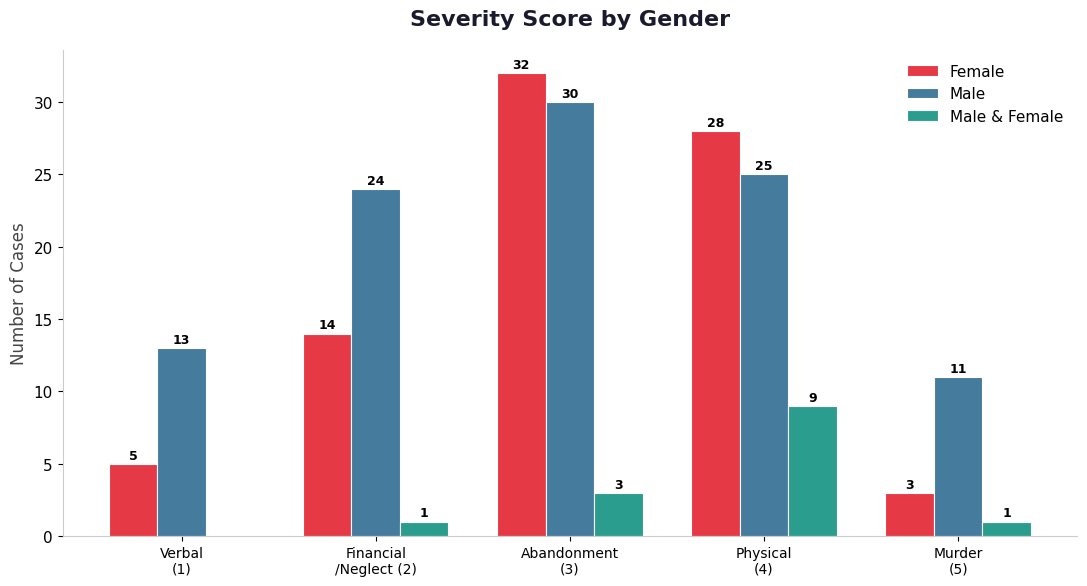

[OK] chart_11_severity_by_gender.png saved


In [122]:
sev_gender = df.groupby(['Severity_Score','Gender']).size().unstack(fill_value=0)
sev_gender = sev_gender.reindex(sorted(sev_gender.index))

gender_colors = {'Male':'#457B9D','Female':'#E63946','Male & Female':'#2A9D8F'}
x    = np.arange(len(sev_gender.index))
cols = [c for c in sev_gender.columns if c in gender_colors]
w    = 0.25

fig, ax = plt.subplots(figsize=(11, 6))
for i, col in enumerate(cols):
    offset = (i - len(cols)/2 + 0.5) * w
    bars_g = ax.bar(x+offset, sev_gender[col], w, label=col,
                    color=gender_colors[col], edgecolor='white', linewidth=0.8)
    for bar in bars_g:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x()+bar.get_width()/2, h+0.15,
                    str(int(h)), ha='center', va='bottom', fontsize=9, fontweight='bold')

sev_xlabels = {1:'Verbal\n(1)', 2:'Financial\n/Neglect (2)',
               3:'Abandonment\n(3)', 4:'Physical\n(4)', 5:'Murder\n(5)'}
ax.set_xticks(x)
ax.set_xticklabels([sev_xlabels.get(s,str(s)) for s in sev_gender.index], fontsize=10)
ax.set_title('Severity Score by Gender', fontsize=16, fontweight='bold', pad=18, color='#1a1a2e')
ax.set_ylabel('Number of Cases', fontsize=12, color='#444')
ax.legend(fontsize=11, frameon=False, loc='upper right')
ax.grid(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
plt.tight_layout()
save_chart('chart_11_severity_by_gender')

## Cell — Step 1 Summary

In [123]:
print('=' * 58)
print('  STEP 1 COMPLETE — Dataset Load & EDA')
print('=' * 58)
print(f'  Total cases          : {len(df)}')
print(f'  Total columns (raw)  : 12')
print(f'  Category (raw)       : {df["Abuse Category"].nunique()} unique (with typos)')
print(f'  Category (normalized): {df["Category_Norm"].nunique()} unique')
print(f'  Relation (normalized): {df["Relation_Norm"].nunique()} unique')
print(f'  Age valid            : {df["Age_Numeric"].notna().sum()} / {len(df)}')
print(f'  Age range            : {int(df["Age_Numeric"].min())} – {int(df["Age_Numeric"].max())} yrs')
print(f'  Trust Blind Spot     : {df["Trust_Blind_Spot"].sum()} cases ({df["Trust_Blind_Spot"].mean()*100:.1f}%)')
print()
print('  Charts saved in data/ folder:')
charts = [
    'chart_01_abuse_category',
    'chart_02_abuser_relation',
    'chart_03_top15_locations',
    'chart_04_gender_pie',
    'chart_05_severity_score',
    'chart_06_age_distribution',
    'chart_07_year_trend',
    'chart_08_heatmap_cat_relation',
    'chart_09_trust_blind_spot',
    'chart_10_data_source_type',
    'chart_11_severity_by_gender',
]
for c in charts:
    print(f'  [OK] {c}.png')
print()
print('  NEXT -> Step 2: Dataset Cleaning + Train/Test Split')
print('=' * 58)

  STEP 1 COMPLETE — Dataset Load & EDA
  Total cases          : 199
  Total columns (raw)  : 12
  Category (raw)       : 18 unique (with typos)
  Category (normalized): 13 unique
  Relation (normalized): 21 unique
  Age valid            : 163 / 199
  Age range            : 40 – 107 yrs
  Trust Blind Spot     : 165 cases (82.9%)

  Charts saved in data/ folder:
  [OK] chart_01_abuse_category.png
  [OK] chart_02_abuser_relation.png
  [OK] chart_03_top15_locations.png
  [OK] chart_04_gender_pie.png
  [OK] chart_05_severity_score.png
  [OK] chart_06_age_distribution.png
  [OK] chart_07_year_trend.png
  [OK] chart_08_heatmap_cat_relation.png
  [OK] chart_09_trust_blind_spot.png
  [OK] chart_10_data_source_type.png
  [OK] chart_11_severity_by_gender.png

  NEXT -> Step 2: Dataset Cleaning + Train/Test Split


---
## Step 2 — Dataset Cleaning + Train/Test Split

### S2-Cell 1 — cleaned_dataset.csv সেভ করো

In [124]:
import os
# Cell 6 এ normalize করা columns সহ পুরো df copy করো
cleaned_df = df.copy()

raw_cols = ['Data Type','Date','Source','Location','Abuse Relation',
            'Abuse Category','Gender','Name','Age','Scenerio(Bangla)',
            'Scenerio(English)','URL / Source type']
new_cols = ['Category_Norm','Relation_Norm','Age_Numeric',
            'Date_Parsed','Year','Severity_Score','Trust_Blind_Spot']

print('Raw columns (12):')
print(raw_cols)
print()
print('New normalized columns (7):')
print([c for c in new_cols if c in cleaned_df.columns])
print(f'Total columns: {len(cleaned_df.columns)}')

# Save
cleaned_df.to_csv('../data/cleaned_dataset.csv', index=False, encoding='utf-8')
size_kb = os.path.getsize('../data/cleaned_dataset.csv') / 1024
print(f'\nSaved: data/cleaned_dataset.csv')
print(f'  Rows    : {len(cleaned_df)}')
print(f'  Columns : {len(cleaned_df.columns)}')
print(f'  Size    : {size_kb:.1f} KB')


Raw columns (12):
['Data Type', 'Date', 'Source', 'Location', 'Abuse Relation', 'Abuse Category', 'Gender', 'Name', 'Age', 'Scenerio(Bangla)', 'Scenerio(English)', 'URL / Source type']

New normalized columns (7):
['Category_Norm', 'Relation_Norm', 'Age_Numeric', 'Date_Parsed', 'Year', 'Severity_Score', 'Trust_Blind_Spot']
Total columns: 20

Saved: data/cleaned_dataset.csv
  Rows    : 199
  Columns : 20
  Size    : 86.1 KB


### S2-Cell 2 — Train/Test Split (80/20, Stratified)

In [125]:
from sklearn.model_selection import train_test_split

# Rare categories (< 2 cases) cannot be stratified
# Fix: merge them into Other for stratify column only
cat_counts   = cleaned_df["Category_Norm"].value_counts()
rare_cats    = cat_counts[cat_counts < 2].index.tolist()
print(f"Rare categories merged for stratify: {rare_cats}")

stratify_col = cleaned_df["Category_Norm"].copy()
stratify_col = stratify_col.where(~stratify_col.isin(rare_cats), other="Other")

train_df, test_df = train_test_split(
    cleaned_df,
    test_size    = 0.20,
    random_state = 42,
    stratify     = stratify_col   # rare categories merged into Other
)

print(f"Total dataset : {len(cleaned_df)} rows")
print(f"Train split   : {len(train_df)} rows (80%)")
print(f"Test split    : {len(test_df)} rows (20%)")
print()

# Verify stratification (actual Category_Norm values)
print("Category distribution — Train vs Test:")
train_dist = train_df["Category_Norm"].value_counts(normalize=True).mul(100).round(1)
test_dist  = test_df["Category_Norm"].value_counts(normalize=True).mul(100).round(1)
dist_check = (
    train_dist.rename("Train %")
    .to_frame()
    .join(test_dist.rename("Test %"), how="outer")
    .fillna(0)
)
print(dist_check.to_string())


Rare categories merged for stratify: ['Financial + Physical + Abandonment', 'Financial + Murder']
Total dataset : 199 rows
Train split   : 159 rows (80%)
Test split    : 40 rows (20%)

Category distribution — Train vs Test:
                                    Train %  Test %
Category_Norm                                      
Abandonment                            22.6    22.5
Financial + Abandonment                 3.8     5.0
Financial + Murder                      0.6     0.0
Financial + Neglect                     1.3     0.0
Financial + Physical                   10.1    10.0
Financial + Physical + Abandonment      0.6     0.0
Financial Exploitation                  1.9     0.0
Murder                                  6.9     7.5
Neglect                                17.0    17.5
Neglect + Abandonment                   6.3     5.0
Physical + Abandonment                  1.3     2.5
Physical Abuse                         18.9    20.0
Verbal Abuse                            8.8    1

### S2-Cell 3 — train_split.csv ও test_split.csv সেভ করো

In [126]:
train_df.to_csv('../data/train_split.csv', index=False, encoding='utf-8')
test_df.to_csv('../data/test_split.csv',   index=False, encoding='utf-8')

print('Saved:')
print(f'  data/train_split.csv  -> {len(train_df)} rows')
print(f'  data/test_split.csv   -> {len(test_df)} rows')


Saved:
  data/train_split.csv  -> 159 rows
  data/test_split.csv   -> 40 rows


### S2-Cell 4 — Step 2 Summary

In [127]:
files = [
    ('../data/cleaned_dataset.csv', 'cleaned_dataset.csv'),
    ('../data/train_split.csv',     'train_split.csv'),
    ('../data/test_split.csv',      'test_split.csv'),
]

print('=' * 55)
print('  STEP 2 COMPLETE — Cleaning + Train/Test Split')
print('=' * 55)
for path, name in files:
    tmp     = pd.read_csv(path, encoding='utf-8')
    size_kb = os.path.getsize(path) / 1024
    print(f'  {name}')
    print(f'    Rows: {len(tmp):>4} | Columns: {len(tmp.columns):>2} | Size: {size_kb:.1f} KB')
print()
print('  NEXT -> Step 3: keyword_dictionary.json')
print('=' * 55)


  STEP 2 COMPLETE — Cleaning + Train/Test Split
  cleaned_dataset.csv
    Rows:  199 | Columns: 20 | Size: 86.1 KB
  train_split.csv
    Rows:  159 | Columns: 20 | Size: 68.7 KB
  test_split.csv
    Rows:   40 | Columns: 20 | Size: 17.6 KB

  NEXT -> Step 3: keyword_dictionary.json


---
## Step 3 — keyword_dictionary.json তৈরি

### S3-Cell 1 — Dataset থেকে Category-wise Common Words বিশ্লেষণ

In [128]:
from collections import Counter
import re

# Category → English scenario গুলো দেখো
# Stopwords বাদ দিয়ে common words বের করো
stopwords = {
    'the','a','an','and','or','but','in','on','at','to','for','of',
    'is','was','were','are','be','been','his','her','their','its',
    'he','she','they','him','who','which','that','this','with','by',
    'from','after','over','as','not','no','so','also','had','have',
    'has','did','do','does','been','into','than','then','when','up',
    'out','it','we','i','you','my','your','our','all','one','two',
    'three','old','elderly','man','woman','father','mother','aged',
    'son','daughter','family','children','child','home','house','was',
}

# Core categories (simple keys)
core_map = {
    'Physical Abuse':                       'physical',
    'Abandonment':                           'abandonment',
    'Neglect':                               'neglect',
    'Financial Exploitation':               'financial',
    'Financial + Physical':                 'physical',
    'Financial + Abandonment':              'abandonment',
    'Financial + Neglect':                  'neglect',
    'Financial + Physical + Abandonment':   'physical',
    'Physical + Abandonment':               'abandonment',
    'Neglect + Abandonment':                'abandonment',
    'Verbal Abuse':                         'verbal',
    'Murder':                               'murder',
    'Financial + Murder':                   'murder',
}

cleaned_df['Core_Category'] = cleaned_df['Category_Norm'].map(core_map)

print('Top 15 English keywords per core category:')
print('=' * 55)
for cat in ['physical','abandonment','neglect','financial','verbal','murder']:
    subset = cleaned_df[cleaned_df['Core_Category'] == cat]['Scenerio(English)'].dropna()
    words  = []
    for text in subset:
        tokens = re.findall(r'[a-z]+', text.lower())
        words.extend([w for w in tokens if w not in stopwords and len(w) > 3])
    top = Counter(words).most_common(15)
    print(f'\n[{cat.upper()}]  ({len(subset)} cases)')
    print(', '.join([f"{w}({c})" for w, c in top]))


Top 15 English keywords per core category:

[PHYSICAL]  (59 cases)
beaten(14), tortured(9), land(9), parents(8), physically(7), sons(7), being(7), property(6), during(6), asking(4), dispute(4), assaulted(4), injuries(4), abused(3), money(3)

[ABANDONMENT]  (68 cases)
abandoned(39), left(12), alone(8), land(6), sons(5), daughters(5), street(4), provide(4), took(3), days(3), neglected(3), forced(3), work(3), becoming(3), without(3)

[NEGLECT]  (36 cases)
neglected(15), food(7), neglect(5), left(4), work(3), doesn(3), despite(3), because(2), even(2), getting(2), give(2), properly(2), eldest(2), currently(2), satying(2)

[FINANCIAL]  (3 cases)
land(2), kurigram(1), body(1), buried(1), hours(1), property(1), division(1), relatives(1), take(1), money(1), expenses(1), forced(1), transfer(1), ownership(1), under(1)

[VERBAL]  (18 cases)
verbally(8), abused(7), left(3), members(3), insulted(3), constantly(3), regularly(2), relatives(2), shouted(2), being(2), depending(2), currently(1), stays(1)

### S3-Cell 2 — keyword_dictionary.json তৈরি

In [129]:
keyword_dict = {

    'physical': {
        'bangla': [
            'মারধর', 'আঘাত', 'চড়', 'লাথি', 'মেরেছে', 'পিটিয়ে',
            'শারীরিক নির্যাতন', 'হাত ভেঙে', 'হাড় ভেঙে', 'আহত',
            'হাসপাতাল', 'রক্ত', 'ব্যথা', 'জখম', 'বেঁধে', 'শিকল'
        ],
        'english': [
            'beat', 'beaten', 'hit', 'slap', 'slapped', 'punch', 'kick',
            'assault', 'assault', 'injury', 'injured', 'hospital',
            'hurt', 'wound', 'attack', 'broke', 'broken', 'fracture',
            'torture', 'tortured', 'chain', 'chained', 'tied', 'violence',
            'physical', 'push', 'pushed', 'drag', 'dragged', 'shaved'
        ],
        'mixed_forms': [
            'beat করেছে', 'hit করেছে', 'slap দিয়েছে',
            'assault করা হয়েছে', 'torture করা হয়েছে'
        ]
    },

    'abandonment': {
        'bangla': [
            'পরিত্যাগ', 'বের করে দিয়েছে', 'তাড়িয়ে দিয়েছে',
            'রাস্তায় ফেলে', 'জঙ্গলে ফেলে', 'একা ফেলে',
            'বৃদ্ধাশ্রমে', 'গৃহহীন', 'বাড়ি ছেড়ে', 'ত্যাগ করেছে',
            'ছেড়ে গেছে', 'নিরাশ্রয়'
        ],
        'english': [
            'abandon', 'abandoned', 'evict', 'evicted', 'thrown out',
            'kicked out', 'left alone', 'street', 'homeless', 'roadside',
            'railway', 'forest', 'old age home', 'shelter', 'deserted',
            'expelled', 'removed', 'flee', 'fled', 'left behind'
        ],
        'mixed_forms': [
            'evict করে দিয়েছে', 'abandon করা হয়েছে',
            'thrown out করা হয়েছে', 'বাড়ি থেকে evict'
        ]
    },

    'neglect': {
        'bangla': [
            'অবহেলা', 'খাবার দেয় না', 'ওষুধ দেয় না', 'যত্ন নেয় না',
            'চিকিৎসা করায় না', 'উপেক্ষা', 'খেতে দেয় না',
            'দেখে না', 'খোঁজ নেয় না', 'একা রেখে যায়',
            'সেবা করে না', 'হাসপাতালে নেয় না'
        ],
        'english': [
            'neglect', 'neglected', 'ignore', 'ignored', 'not feeding',
            'no food', 'no medicine', 'not caring', 'deprive', 'deprived',
            'starvation', 'medical', 'treatment', 'healthcare', 'alone',
            'not taken', 'denied', 'without food', 'without medicine'
        ],
        'mixed_forms': [
            'medicine দেয় না', 'care করে না',
            'food দেয় না', 'hospital নেয় না'
        ]
    },

    'financial': {
        'bangla': [
            'সম্পত্তি', 'জমি', 'টাকা', 'দলিল', 'নিবন্ধন',
            'পেনশন', 'ব্যাংক', 'আত্মসাৎ', 'প্রতারণা', 'চুরি',
            'ভাতা', 'মালিকানা', 'বিক্রি', 'হস্তান্তর', 'দখল'
        ],
        'english': [
            'property', 'land', 'money', 'wealth', 'pension', 'deed',
            'register', 'assets', 'inheritance', 'savings', 'bank',
            'account', 'fraud', 'cheat', 'steal', 'stolen', 'forced',
            'sign', 'transfer', 'ownership', 'sold', 'dispossess'
        ],
        'mixed_forms': [
            'property নিয়েছে', 'land transfer করেছে',
            'account থেকে টাকা নিয়েছে', 'deed লিখিয়ে নিয়েছে'
        ]
    },

    'verbal': {
        'bangla': [
            'গালি', 'অপমান', 'হুমকি', 'ভয় দেখানো', 'মৌখিক নির্যাতন',
            'তিরস্কার', 'চিৎকার', 'বকাঝকা', 'অভিশাপ', 'রাগারাগি',
            'অকর্মণ্য বলা', 'বোঝা মনে করা'
        ],
        'english': [
            'insult', 'insultd', 'verbal', 'abuse', 'shout', 'shouted',
            'threaten', 'threat', 'humiliate', 'humiliated', 'curse',
            'scold', 'disrespect', 'yell', 'abusive', 'intimidate',
            'called useless', 'blamed', 'cursed'
        ],
        'mixed_forms': [
            'threaten করেছে', 'insult করে',
            'verbal abuse করা হয়েছে'
        ]
    },

    'murder': {
        'bangla': [
            'হত্যা', 'খুন', 'নিহত', 'মেরে ফেলা', 'হত্যা করে',
            'লাশ', 'মরদেহ', 'দাফন', 'কুপিয়ে', 'ছুরিকাঘাত',
            'শ্বাসরোধ', 'আত্মহত্যা'
        ],
        'english': [
            'kill', 'killed', 'murder', 'murdered', 'death', 'dead',
            'stab', 'stabbed', 'beat to death', 'strangle', 'strangled',
            'hack', 'hacked', 'bury', 'buried', 'body', 'corpse',
            'suicide', 'slaughter'
        ],
        'mixed_forms': [
            'murder করেছে', 'kill করেছে',
            'হত্যা করে body bury করেছে'
        ]
    }
}

# Summary
print('keyword_dictionary.json — Summary')
print('=' * 45)
total_keywords = 0
for cat, kws in keyword_dict.items():
    bn = len(kws['bangla'])
    en = len(kws['english'])
    mx = len(kws['mixed_forms'])
    total_keywords += bn + en + mx
    print(f'  {cat:<14}: Bangla={bn:2} | English={en:2} | Mixed={mx}')
print(f'\n  Total keywords: {total_keywords}')


keyword_dictionary.json — Summary
  physical      : Bangla=16 | English=30 | Mixed=5
  abandonment   : Bangla=12 | English=20 | Mixed=4
  neglect       : Bangla=12 | English=19 | Mixed=4
  financial     : Bangla=15 | English=22 | Mixed=4
  verbal        : Bangla=12 | English=19 | Mixed=3
  murder        : Bangla=12 | English=19 | Mixed=3

  Total keywords: 231


### S3-Cell 3 — backend/phase1_outputs/ এ সেভ করো

In [130]:
import json as _json

out_path = '../backend/phase1_outputs/keyword_dictionary.json'

with open(out_path, 'w', encoding='utf-8') as f:
    _json.dump(keyword_dict, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(out_path) / 1024
print(f'Saved: {out_path}')
print(f'  Size: {size_kb:.1f} KB')
print()

# Verify — reload করে দেখো
with open(out_path, 'r', encoding='utf-8') as f:
    loaded = _json.load(f)

print('Verify — Categories in file:')
for cat in loaded:
    bn = len(loaded[cat]['bangla'])
    en = len(loaded[cat]['english'])
    print(f'  {cat:<14}: {bn} Bangla + {en} English keywords')


Saved: ../backend/phase1_outputs/keyword_dictionary.json
  Size: 6.4 KB

Verify — Categories in file:
  physical      : 16 Bangla + 30 English keywords
  abandonment   : 12 Bangla + 20 English keywords
  neglect       : 12 Bangla + 19 English keywords
  financial     : 15 Bangla + 22 English keywords
  verbal        : 12 Bangla + 19 English keywords
  murder        : 12 Bangla + 19 English keywords


### S3-Cell 4 — Quick Classifier Test (keyword_dictionary দিয়ে)

In [131]:
def quick_classify(text: str, kw_dict: dict) -> dict:
    text_lower = text.lower()
    scores = {}
    for category, kw_group in kw_dict.items():
        all_kw = (
            kw_group.get('bangla', []) +
            kw_group.get('english', []) +
            kw_group.get('mixed_forms', [])
        )
        scores[category] = sum(1 for kw in all_kw if kw.lower() in text_lower)

    if not any(scores.values()):
        return {'category': 'unknown', 'confidence': 0.0}

    top   = max(scores, key=scores.get)
    total = sum(scores.values())
    conf  = round(scores[top] / total, 2)
    return {'category': top, 'confidence': conf, 'all_scores': scores}

# Test cases
test_cases = [
    'Son beats elderly father and causes injury',
    'Mother was abandoned on the street by her children',
    'Family neglected him and gave no food or medicine',
    'Son forced father to transfer property and land deed',
    'He was verbally abused and insulted by his son',
    'Son murdered his father and buried the body',
    'ছেলে বাবাকে মারধর করেছে এবং আহত করেছে',
    'পরিবার তাকে পরিত্যাগ করে রাস্তায় ফেলে দিয়েছে',
    'সম্পত্তি নিয়ে জোর করে দলিল লিখিয়ে নিয়েছে',
]

print('Quick Classifier Test Results:')
print('=' * 55)
for text in test_cases:
    result = quick_classify(text, keyword_dict)
    print(f'  [{result["category"]:<14}] ({result["confidence"]:.0%}) → {text[:50]}...')


Quick Classifier Test Results:
  [physical      ] (100%) → Son beats elderly father and causes injury...
  [abandonment   ] (100%) → Mother was abandoned on the street by her children...
  [neglect       ] (100%) → Family neglected him and gave no food or medicine...
  [financial     ] (100%) → Son forced father to transfer property and land de...
  [verbal        ] (100%) → He was verbally abused and insulted by his son...
  [murder        ] (100%) → Son murdered his father and buried the body...
  [physical      ] (100%) → ছেলে বাবাকে মারধর করেছে এবং আহত করেছে...
  [abandonment   ] (100%) → পরিবার তাকে পরিত্যাগ করে রাস্তায় ফেলে দিয়েছে...
  [financial     ] (100%) → সম্পত্তি নিয়ে জোর করে দলিল লিখিয়ে নিয়েছে...


### S3-Cell 5 — Step 3 Summary

In [132]:
import os

kw_path = '../backend/phase1_outputs/keyword_dictionary.json'
size_kb = os.path.getsize(kw_path) / 1024

print('=' * 55)
print('  STEP 3 COMPLETE — keyword_dictionary.json')
print('=' * 55)
print(f'  File : backend/phase1_outputs/keyword_dictionary.json')
print(f'  Size : {size_kb:.1f} KB')
print(f'  Categories : {len(keyword_dict)}')
total = sum(
    len(v["bangla"]) + len(v["english"]) + len(v["mixed_forms"])
    for v in keyword_dict.values()
)
print(f'  Total keywords : {total}')
print()
print('  NEXT -> Step 4: act_knowledge_base.json')
print('=' * 55)


  STEP 3 COMPLETE — keyword_dictionary.json
  File : backend/phase1_outputs/keyword_dictionary.json
  Size : 6.4 KB
  Categories : 6
  Total keywords : 231

  NEXT -> Step 4: act_knowledge_base.json


---
## Step 4 — act_knowledge_base.json তৈরি

> **Source:** পিতা-মাতার ভরণ-পোষণ আইন, ২০১৩ (Act No. 49 of 2013)  
> **Verified via:** bdlaws.minlaw.gov.bd + ILO NatLex database  
> **Note on penalty correction:** আগে ৫,০০০ টাকা/১ মাস জানা ছিল — আসল আইনে **১,০০,০০০ টাকা/৩ মাস**

### S4-Cell 1 — act_knowledge_base.json বানানো (PMA 2013 + BPC)

In [133]:
knowledge_base = {

    # ════════════════════════════════════════════════════════
    # পিতা-মাতার ভরণ-পোষণ আইন, ২০১৩ (Act No. 49 of 2013)
    # ════════════════════════════════════════════════════════

    'pma_sec1': {
        'section': 'PMA 2013 — Section 1: Short Title and Commencement',
        'text': (
            'এই আইন পিতা-মাতার ভরণ-পোষণ আইন, ২০১৩ নামে পরিচিত হইবে। '
            'এই আইন ২৭ অক্টোবর ২০১৩ তারিখে কার্যকর হয়। '
            'এটি ২০১৩ সনের ৪৯ নং আইন।'
        ),
        'text_english': (
            'This Act may be called the Parents Maintenance Act, 2013. '
            'It came into force on 27 October 2013. This is Act No. 49 of 2013.'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    'pma_sec2': {
        'section': 'PMA 2013 — Section 2: Definitions',
        'text': (
            'এই আইনে — '
            '"পিতা" অর্থ যে ব্যক্তি সন্তানকে জন্মদান করিয়াছেন (শুধু জন্মদাতা, সৎ পিতা নহে); '
            '"মাতা" অর্থ যে নারী সন্তানকে গর্ভে ধারণ ও প্রসব করিয়াছেন (শুধু জন্মদাত্রী, সৎ মাতা নহে); '
            '"সন্তান" অর্থ পুত্র ও কন্যা উভয়ই, বিবাহিত বা অবিবাহিত; '
            '"ভরণ-পোষণ" অর্থ খাদ্য, বস্ত্র, চিকিৎসা সেবা, বাসস্থান এবং সঙ্গ প্রদান; '
            '"উপজেলা নির্বাহী অফিসার" (UNO) অর্থ সংশ্লিষ্ট উপজেলার নির্বাহী কর্মকর্তা।'
        ),
        'text_english': (
            'In this Act: '
            '"Father" means biological father only (step-father excluded); '
            '"Mother" means biological mother only (step-mother excluded); '
            '"Child" means both son and daughter, married or unmarried; '
            '"Maintenance" means food, clothing, medical care, shelter AND companionship; '
            '"UNO" means Upazila Nirbahi Officer of the concerned upazila.'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    'pma_sec3': {
        'section': 'PMA 2013 — Section 3: Maintenance Obligation',
        'text': (
            'প্রতিটি সন্তান তাদের পিতামাতার ভরণ-পোষণ করিতে বাধ্য। '
            'পিতামাতা যদি সন্তানের সাথে না থাকেন, তাহলে প্রতিটি সন্তান নিজ আয় বা সম্পদ হইতে '
            'পিতামাতার জন্য যুক্তিসংগত পরিমাণ অর্থ প্রদান করিবে। '
            'একাধিক সন্তান থাকিলে, তাহারা পরস্পর আলাপ-আলোচনার মাধ্যমে ভরণ-পোষণের ব্যবস্থা করিবে। '
            'সন্তান পিতামাতাকে তাহার বাসস্থানে রাখিবে এবং পিতামাতার সহিত বসবাস করিবে। '
            'পিতামাতাকে তাহাদের ইচ্ছার বিরুদ্ধে বৃদ্ধাশ্রমে পাঠানো যাইবে না। '
            'পিতামাতার অনুপস্থিতিতে পিতার পিতামাতা (দাদা-দাদি) এবং মাতার পিতামাতা (নানা-নানি) '
            'একইরূপে ভরণ-পোষণ পাইবার অধিকারী।'
        ),
        'text_english': (
            'Every child is obligated to maintain their parents. '
            'If parents do not live with the child, each child shall provide a reasonable amount '
            'from their income or assets for parents maintenance. '
            'If there are multiple children, they shall collectively arrange maintenance through mutual discussion. '
            'Children must accommodate parents in their residence. '
            'Parents cannot be sent to an old-age home against their will. '
            'In the absence of parents, paternal grandparents and maternal grandparents '
            'are equally entitled to maintenance.'
        ),
        'applicable_for': ['neglect', 'abandonment', 'financial'],
        'severity_min': 2
    },

    'pma_sec4': {
        'section': 'PMA 2013 — Section 4: Prohibition of Medical Neglect and Abandonment',
        'text': (
            'কোনো সন্তান পিতামাতার চিকিৎসা সেবা প্রদান হইতে বিরত থাকিবে না। '
            'পিতামাতাকে পরিত্যাগ করা বা গৃহহীন করা সম্পূর্ণ নিষিদ্ধ। '
            'সন্তান পিতামাতার নিয়মিত স্বাস্থ্য পরীক্ষা নিশ্চিত করিবে। '
            'পিতামাতা আলাদা বসবাস করিলেও সন্তান নিয়মিত তাহাদের দেখিতে যাইবে।'
        ),
        'text_english': (
            'No child shall withhold medical care from parents. '
            'Abandoning or making parents homeless is completely prohibited. '
            'Children must ensure regular health check-ups for parents. '
            'Even if parents live separately, children must visit them regularly.'
        ),
        'applicable_for': ['neglect', 'abandonment'],
        'severity_min': 2
    },

    'pma_sec5': {
        'section': 'PMA 2013 — Section 5: Complaint Procedure (UNO)',
        'text': (
            'কোনো পিতা বা মাতা ভরণ-পোষণ না পাইলে সংশ্লিষ্ট উপজেলার উপজেলা নির্বাহী অফিসার '
            '(UNO) বরাবর লিখিত অভিযোগ দাখিল করিতে পারিবেন। '
            'শুধুমাত্র পিতামাতা নিজে অভিযোগ করিতে পারিবেন; আদালত স্বতঃপ্রণোদিতভাবে মামলা গ্রহণ করিতে পারিবে না। '
            'অভিযোগ প্রাপ্তির পর UNO উভয় পক্ষকে শুনানির জন্য সমন প্রদান করিবেন। '
            'ইউনিয়ন পরিষদের চেয়ারম্যান বা পৌরসভার মেয়রও আপোষ মীমাংসার ব্যবস্থা করিতে পারিবেন। '
            'অপরাধ আমলযোগ্য (Cognizable), জামিনযোগ্য (Bailable) এবং আপোষযোগ্য (Compoundable)।'
        ),
        'text_english': (
            'If any parent does not receive maintenance, they may file a written complaint '
            'with the Upazila Nirbahi Officer (UNO) of the concerned upazila. '
            'Only parents themselves can file complaints; courts cannot take suo motu cognizance. '
            'Upon receiving complaint, UNO shall summon both parties for hearing. '
            'Union Council chairpersons or municipal mayors can also mediate amicable settlements. '
            'The offence is Cognizable, Bailable and Compoundable.'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    'pma_sec6': {
        'section': 'PMA 2013 — Section 6: Powers of UNO',
        'text': (
            'উপজেলা নির্বাহী অফিসার (UNO) অভিযোগ তদন্ত করিবেন এবং উভয় পক্ষ শুনানির সুযোগ দিবেন। '
            'UNO প্রয়োজনে মধ্যস্থতার মাধ্যমে আপোষ মীমাংসার ব্যবস্থা করিতে পারিবেন। '
            'UNO সন্তানকে নির্দিষ্ট পরিমাণ ভরণ-পোষণ প্রদানের আদেশ দিতে পারিবেন। '
            'আদেশ অমান্য করিলে UNO বিষয়টি দণ্ড আরোপের জন্য প্রেরণ করিবেন।'
        ),
        'text_english': (
            'The UNO shall investigate the complaint and give both parties opportunity to be heard. '
            'UNO may facilitate amicable settlement through mediation. '
            'UNO can order the child to pay a specified amount for maintenance. '
            'If the order is defied, UNO shall refer the matter for penalty imposition.'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    'pma_sec7': {
        'section': 'PMA 2013 — Section 7: Penalty (Punishment)',
        'text': (
            'এই আইনের কোনো বিধান লঙ্ঘন করিলে সন্তান অনূর্ধ্ব ১,০০,০০০ (এক লক্ষ) টাকা অর্থদণ্ডে দণ্ডিত হইবেন। '
            'অর্থদণ্ড অনাদায়ের ক্ষেত্রে অনূর্ধ্ব ৩ (তিন) মাস কারাদণ্ডে দণ্ডিত হইবেন। '
            '[সংশোধনী নোট: আগে ৫,০০০ টাকা ও ১ মাস কারাদণ্ড ছিল — bdlaws যাচাই করে সংশোধন করা হয়েছে।]'
        ),
        'text_english': (
            'Violation of any provision of this Act shall be punishable with a fine '
            'not exceeding Taka 1,00,000 (one lakh). '
            'In case of non-payment, imprisonment not exceeding 3 (three) months. '
            '[Correction note: Previously stated as 5,000 taka/1 month — corrected after bdlaws verification.]'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    'pma_sec8': {
        'section': 'PMA 2013 — Section 8: Emergency and Interim Assistance',
        'text': (
            'জরুরি পরিস্থিতিতে UNO অন্তর্বর্তীকালীন আদেশ দিতে পারিবেন। '
            'বিপদে পড়া পিতামাতাকে তাৎক্ষণিক সহায়তা দেওয়ার ব্যবস্থা করিতে হইবে।'
        ),
        'text_english': (
            'In emergency situations, the UNO may issue interim orders. '
            'Arrangements must be made for immediate assistance to parents in distress.'
        ),
        'applicable_for': ['all'],
        'severity_min': 4
    },

    'pma_sec9': {
        'section': 'PMA 2013 — Section 9: Rules / Savings',
        'text': (
            'সরকার এই আইনের উদ্দেশ্য পূরণকল্পে বিধিমালা প্রণয়ন করিতে পারিবে। '
            '[নোট: Section 9 এর সম্পূর্ণ পাঠ্য bdlaws থেকে সরাসরি verify করা প্রয়োজন।]'
        ),
        'text_english': (
            'The government may make rules for the purpose of this Act. '
            '[Note: Section 9 full text needs direct verification from bdlaws.minlaw.gov.bd]'
        ),
        'applicable_for': ['all'],
        'severity_min': 1
    },

    # ════════════════════════════════════════════════════════
    # Bangladesh Penal Code (BPC) — Relevant Sections
    # ════════════════════════════════════════════════════════

    'bpc_302': {
        'section': 'BPC Section 302 — Punishment for Murder',
        'text': (
            'যে ব্যক্তি হত্যাকাণ্ড ঘটায় তাকে মৃত্যুদণ্ড বা যাবজ্জীবন কারাদণ্ড এবং '
            'অর্থদণ্ডে দণ্ডিত করা হইবে।'
        ),
        'text_english': (
            'Whoever commits murder shall be punished with death or imprisonment for life, '
            'and shall also be liable to fine.'
        ),
        'applicable_for': ['murder'],
        'severity_min': 5
    },

    'bpc_304': {
        'section': 'BPC Section 304 — Culpable Homicide (Not Murder)',
        'text': (
            'অনিচ্ছাকৃত হত্যার ক্ষেত্রে যাবজ্জীবন কারাদণ্ড বা ১০ বছর পর্যন্ত কারাদণ্ড '
            'এবং অর্থদণ্ড হইবে।'
        ),
        'text_english': (
            'Culpable homicide not amounting to murder: imprisonment for life or up to 10 years, '
            'and fine.'
        ),
        'applicable_for': ['murder'],
        'severity_min': 5
    },

    'bpc_323': {
        'section': 'BPC Section 323 — Voluntarily Causing Hurt',
        'text': (
            'যে ব্যক্তি স্বেচ্ছায় কাউকে আঘাত করে তাকে ১ বছর পর্যন্ত কারাদণ্ড বা '
            '১,০০০ টাকা পর্যন্ত অর্থদণ্ড অথবা উভয় দণ্ডে দণ্ডিত করা হইবে।'
        ),
        'text_english': (
            'Whoever voluntarily causes hurt shall be punished with imprisonment up to 1 year, '
            'or fine up to Taka 1,000, or both.'
        ),
        'applicable_for': ['physical'],
        'severity_min': 4
    },

    'bpc_324': {
        'section': 'BPC Section 324 — Causing Hurt by Dangerous Weapon',
        'text': (
            'বিপজ্জনক অস্ত্র দ্বারা আঘাত করিলে ৩ বছর পর্যন্ত কারাদণ্ড বা '
            'অর্থদণ্ড অথবা উভয় দণ্ড হইবে।'
        ),
        'text_english': (
            'Voluntarily causing hurt by dangerous weapons: imprisonment up to 3 years, '
            'or fine, or both.'
        ),
        'applicable_for': ['physical'],
        'severity_min': 4
    },

    'bpc_406': {
        'section': 'BPC Section 406 — Criminal Breach of Trust',
        'text': (
            'বিশ্বাস ভঙ্গ করিয়া সম্পত্তি আত্মসাৎ করিলে ৩ বছর পর্যন্ত কারাদণ্ড বা '
            'অর্থদণ্ড অথবা উভয় দণ্ডে দণ্ডিত হইবে।'
        ),
        'text_english': (
            'Whoever commits criminal breach of trust shall be punished with imprisonment '
            'up to 3 years, or fine, or both.'
        ),
        'applicable_for': ['financial'],
        'severity_min': 2
    },

    'bpc_420': {
        'section': 'BPC Section 420 — Cheating and Property Fraud',
        'text': (
            'প্রতারণা করিয়া সম্পত্তি হাতিয়ে নিলে ৭ বছর পর্যন্ত কারাদণ্ড এবং '
            'অর্থদণ্ডে দণ্ডিত হইবে।'
        ),
        'text_english': (
            'Cheating and dishonestly inducing delivery of property: imprisonment up to 7 years '
            'and fine.'
        ),
        'applicable_for': ['financial'],
        'severity_min': 2
    },

    'bpc_506': {
        'section': 'BPC Section 506 — Criminal Intimidation (Threat)',
        'text': (
            'কাউকে ভয় দেখাইলে ২ বছর পর্যন্ত কারাদণ্ড বা অর্থদণ্ড অথবা উভয় দণ্ড হইবে। '
            'মৃত্যু বা গুরুতর ক্ষতির হুমকি দিলে ৭ বছর পর্যন্ত কারাদণ্ড।'
        ),
        'text_english': (
            'Criminal intimidation: imprisonment up to 2 years, or fine, or both. '
            'If threat be of death or grievous hurt: up to 7 years imprisonment.'
        ),
        'applicable_for': ['verbal'],
        'severity_min': 1
    },
}

# Summary
print('act_knowledge_base.json — Summary')
print('=' * 55)
pma_sections = [k for k in knowledge_base if k.startswith('pma')]
bpc_sections = [k for k in knowledge_base if k.startswith('bpc')]
print(f'  PMA 2013 sections : {len(pma_sections)}')
print(f'  BPC sections      : {len(bpc_sections)}')
print(f'  Total sections    : {len(knowledge_base)}')
print()
print('  Key correction applied:')
print('  Penalty: 5,000 taka/1 month  -->  1,00,000 taka/3 months')


act_knowledge_base.json — Summary
  PMA 2013 sections : 9
  BPC sections      : 7
  Total sections    : 16

  Key correction applied:
  Penalty: 5,000 taka/1 month  -->  1,00,000 taka/3 months


### S4-Cell 2 — backend/phase1_outputs/ এ সেভ করো

In [134]:
import json as _json, os

out_path = '../backend/phase1_outputs/act_knowledge_base.json'

with open(out_path, 'w', encoding='utf-8') as f:
    _json.dump(knowledge_base, f, ensure_ascii=False, indent=2)

size_kb = os.path.getsize(out_path) / 1024
print(f'Saved: {out_path}')
print(f'  Size    : {size_kb:.1f} KB')
print(f'  Sections: {len(knowledge_base)}')
print()

# Verify
with open(out_path, 'r', encoding='utf-8') as f:
    loaded = _json.load(f)
print('Verified sections:')
for key, val in loaded.items():
    print(f'  {key:<12} -> {val["section"][:55]}')


Saved: ../backend/phase1_outputs/act_knowledge_base.json
  Size    : 14.7 KB
  Sections: 16

Verified sections:
  pma_sec1     -> PMA 2013 — Section 1: Short Title and Commencement
  pma_sec2     -> PMA 2013 — Section 2: Definitions
  pma_sec3     -> PMA 2013 — Section 3: Maintenance Obligation
  pma_sec4     -> PMA 2013 — Section 4: Prohibition of Medical Neglect an
  pma_sec5     -> PMA 2013 — Section 5: Complaint Procedure (UNO)
  pma_sec6     -> PMA 2013 — Section 6: Powers of UNO
  pma_sec7     -> PMA 2013 — Section 7: Penalty (Punishment)
  pma_sec8     -> PMA 2013 — Section 8: Emergency and Interim Assistance
  pma_sec9     -> PMA 2013 — Section 9: Rules / Savings
  bpc_302      -> BPC Section 302 — Punishment for Murder
  bpc_304      -> BPC Section 304 — Culpable Homicide (Not Murder)
  bpc_323      -> BPC Section 323 — Voluntarily Causing Hurt
  bpc_324      -> BPC Section 324 — Causing Hurt by Dangerous Weapon
  bpc_406      -> BPC Section 406 — Criminal Breach of Trust
  bp

### S4-Cell 3 — Quick RAG Simulation Test

In [135]:
# Simple keyword-based retrieval test (ChromaDB এর আগে)
def simple_retrieve(query: str, kb: dict, top_k: int = 3) -> list:
    query_lower = query.lower()
    scores = {}
    for key, val in kb.items():
        text = (val['text'] + ' ' + val['text_english']).lower()
        # Score = overlapping words
        q_words = set(query_lower.split())
        t_words = set(text.split())
        scores[key] = len(q_words & t_words)
    top = sorted(scores, key=scores.get, reverse=True)[:top_k]
    return [(k, knowledge_base[k]['section']) for k in top if scores[k] > 0]

test_queries = [
    'son beats father physical injury hospital',
    'abandoned mother street homeless',
    'property land fraud forced signature',
    'son murdered father buried body',
    'verbal threat intimidation',
    'maintenance penalty punishment fine',
    'UNO complaint procedure filing',
]

print('Simple RAG Retrieval Test:')
print('=' * 60)
for q in test_queries:
    results = simple_retrieve(q, knowledge_base)
    print(f'\nQuery: "{q}"')
    for key, section in results:
        print(f'  -> [{key}] {section[:50]}')


Simple RAG Retrieval Test:

Query: "son beats father physical injury hospital"
  -> [pma_sec2] PMA 2013 — Section 2: Definitions

Query: "abandoned mother street homeless"
  -> [pma_sec2] PMA 2013 — Section 2: Definitions
  -> [pma_sec4] PMA 2013 — Section 4: Prohibition of Medical Negle

Query: "property land fraud forced signature"

Query: "son murdered father buried body"
  -> [pma_sec2] PMA 2013 — Section 2: Definitions

Query: "verbal threat intimidation"
  -> [bpc_506] BPC Section 506 — Criminal Intimidation (Threat)

Query: "maintenance penalty punishment fine"
  -> [pma_sec1] PMA 2013 — Section 1: Short Title and Commencement
  -> [pma_sec3] PMA 2013 — Section 3: Maintenance Obligation
  -> [pma_sec6] PMA 2013 — Section 6: Powers of UNO

Query: "UNO complaint procedure filing"
  -> [pma_sec5] PMA 2013 — Section 5: Complaint Procedure (UNO)
  -> [pma_sec6] PMA 2013 — Section 6: Powers of UNO
  -> [pma_sec8] PMA 2013 — Section 8: Emergency and Interim Assist


### S4-Cell 4 — Step 4 Summary

In [136]:
kb_path = '../backend/phase1_outputs/act_knowledge_base.json'
size_kb = os.path.getsize(kb_path) / 1024

print('=' * 58)
print('  STEP 4 COMPLETE — act_knowledge_base.json')
print('=' * 58)
print(f'  File     : backend/phase1_outputs/act_knowledge_base.json')
print(f'  Size     : {size_kb:.1f} KB')
print(f'  Sections : {len(knowledge_base)}')
print(f'    PMA 2013 : {len([k for k in knowledge_base if k.startswith("pma")])} sections')
print(f'    BPC      : {len([k for k in knowledge_base if k.startswith("bpc")])} sections')
print()
print('  Corrections applied from bdlaws research:')
print('  [FIX] Penalty: 5,000 taka/1 month --> 1,00,000 taka/3 months')
print('  [ADD] Cognizable + Bailable + Compoundable nature')
print('  [ADD] Only parents can file (no suo motu)')
print('  [ADD] Old age home prohibition')
print('  [ADD] Companionship in maintenance definition')
print('  [ADD] Grandparents entitled')
print('  [ADD] Local council mediation option')
print()
print('  PHASE 1 COMPLETE -- All 4 Steps Done!')
print('  NEXT -> Phase 2: Backend + Whisper Setup')
print('=' * 58)


  STEP 4 COMPLETE — act_knowledge_base.json
  File     : backend/phase1_outputs/act_knowledge_base.json
  Size     : 14.7 KB
  Sections : 16
    PMA 2013 : 9 sections
    BPC      : 7 sections

  Corrections applied from bdlaws research:
  [FIX] Penalty: 5,000 taka/1 month --> 1,00,000 taka/3 months
  [ADD] Cognizable + Bailable + Compoundable nature
  [ADD] Only parents can file (no suo motu)
  [ADD] Old age home prohibition
  [ADD] Companionship in maintenance definition
  [ADD] Grandparents entitled
  [ADD] Local council mediation option

  PHASE 1 COMPLETE -- All 4 Steps Done!
  NEXT -> Phase 2: Backend + Whisper Setup
